In [24]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [25]:

!pip install PyWavelets --quiet
from google.colab import drive
import os
import numpy as np
import pandas as pd
import pywt
from scipy.signal import butter, filtfilt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
import re
from pathlib import Path

In [26]:

DATA_FOLDER = '/content/drive/MyDrive/classes'


OUTPUT_FOLDER = '/content/drive/MyDrive/EOG_Output'

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Class mapping
CLASS_MAP = {
    'yukari': 'Up',
    'asagi':  'Down',
    'sag':    'Right',
    'sol':    'Left',
    'kirp':   'Blink'
}
VALID_CLASSES = list(CLASS_MAP.keys())
VALID_CHANNELS = ['h', 'v']


def get_trial(file_number):
    if 1  <= file_number <= 5:  return 1
    if 6  <= file_number <= 10: return 2
    if 11 <= file_number <= 15: return 3
    if 16 <= file_number <= 20: return 4
    return None

print(' Configuration done')

 Configuration done


In [27]:

def parse_filename(filename):


    name = filename.replace('.txt', '').lower()

    for cls in sorted(VALID_CLASSES, key=len, reverse=True):

        if name.startswith(cls):
            rest = name[len(cls):]

            match = re.match(r'^(\d+)([hv])$', rest)
            if match:
                return cls, int(match.group(1)), match.group(2)
    return None, None, None


all_files = []
skipped = []

for fname in os.listdir(DATA_FOLDER):
    if not fname.endswith('.txt'):
        skipped.append((fname, 'not .txt'))
        continue

    cls, num, ch = parse_filename(fname)

    if cls is None:
        skipped.append((fname, 'not'))
        continue

    if num < 1 or num > 20:
        skipped.append((fname, f' {num} out 1-20'))
        continue

    trial = get_trial(num)
    fpath = os.path.join(DATA_FOLDER, fname)


    try:
        signal = pd.read_csv(fpath, header=None).squeeze().values.astype(float)
    except Exception as e:
        skipped.append((fname, f' {e}'))
        continue

    all_files.append({
        'filename': fname,
        'class_raw': cls,
        'class_label': CLASS_MAP[cls],
        'file_number': num,
        'trial': trial,
        'channel': ch.upper(),
        'signal': signal,
        'signal_length': len(signal)
    })

print(f'✅  {len(all_files)}')
print(f'⚠️  {len(skipped)}')
# if skipped:
#     for s in skipped:
#         print(f'   - {s[0]}: {s[1]}')

✅  200
⚠️  78


In [28]:


df_meta = pd.DataFrame([{
    'filename': f['filename'],
    'class': f['class_label'],
    'trial': f['trial'],
    'channel': f['channel'],
    'signal_length': f['signal_length']
} for f in all_files])


if df_meta.empty:
    print("⚠️ No data was loaded. Please ensure 'all_files' list is populated in the previous cell(s).")
    print("This typically indicates an issue with the DATA_FOLDER path or that no files were found.")
else:

    print(df_meta.groupby(['class', 'channel', 'trial']).size().to_string())
    print(f'\nlen(min/max): {df_meta.signal_length.min()} / {df_meta.signal_length.max()}')


    counts = df_meta.groupby('class').size()
    print('\n===#files===')
    for cls, cnt in counts.items():
        status = '✅' if cnt == 40 else '⚠️ '
        print(f'  {status} {cls}: {cnt} ')

class  channel  trial
Blink  H        1        5
                2        5
                3        5
                4        5
       V        1        5
                2        5
                3        5
                4        5
Down   H        1        5
                2        5
                3        5
                4        5
       V        1        5
                2        5
                3        5
                4        5
Left   H        1        5
                2        5
                3        5
                4        5
       V        1        5
                2        5
                3        5
                4        5
Right  H        1        5
                2        5
                3        5
                4        5
       V        1        5
                2        5
                3        5
                4        5
Up     H        1        5
                2        5
                3        5
                4        5
      

In [29]:


def build_split_by_channel(files_list, train_trials, test_trials, channel):

    train_rows = []
    test_rows  = []

    for f in files_list:
        if f['channel'] != channel:
            continue
        row = {
            'class_label': f['class_label'],
            'class_raw':   f['class_raw'],
            'trial':       f['trial'],
            'filename':    f['filename']
        }
        for i, val in enumerate(f['signal']):
            row[f'signal_{i}'] = val

        if f['trial'] in train_trials:
            train_rows.append(row)
        elif f['trial'] in test_trials:
            test_rows.append(row)

    return pd.DataFrame(train_rows), pd.DataFrame(test_rows)


# 4-Fold Cross Validation
folds = [
    {'round': 1, 'train': [1,2,3], 'test': [4]},
    {'round': 2, 'train': [1,2,4], 'test': [3]},
    {'round': 3, 'train': [1,3,4], 'test': [2]},
    {'round': 4, 'train': [2,3,4], 'test': [1]},
]

for fold in folds:
    r = fold['round']

    for ch in ['H', 'V']:
        df_train, df_test = build_split_by_channel(
            all_files, fold['train'], fold['test'], channel=ch
        )

        train_path = os.path.join(OUTPUT_FOLDER, f'Round{r}_Train_{ch}.xlsx')
        test_path  = os.path.join(OUTPUT_FOLDER, f'Round{r}_Test_{ch}.xlsx')

        df_train.to_excel(train_path, index=False)
        df_test.to_excel(test_path,  index=False)

        print(f'✅ Round {r} | {ch}: Train={len(df_train)}  → {os.path.basename(train_path)}')
        print(f'             Test ={len(df_test)}   → {os.path.basename(test_path)}')

    print()

print('🎉', OUTPUT_FOLDER)

✅ Round 1 | H: Train=75  → Round1_Train_H.xlsx
             Test =25   → Round1_Test_H.xlsx
✅ Round 1 | V: Train=75  → Round1_Train_V.xlsx
             Test =25   → Round1_Test_V.xlsx

✅ Round 2 | H: Train=75  → Round2_Train_H.xlsx
             Test =25   → Round2_Test_H.xlsx
✅ Round 2 | V: Train=75  → Round2_Train_V.xlsx
             Test =25   → Round2_Test_V.xlsx

✅ Round 3 | H: Train=75  → Round3_Train_H.xlsx
             Test =25   → Round3_Test_H.xlsx
✅ Round 3 | V: Train=75  → Round3_Train_V.xlsx
             Test =25   → Round3_Test_V.xlsx

✅ Round 4 | H: Train=75  → Round4_Train_H.xlsx
             Test =25   → Round4_Test_H.xlsx
✅ Round 4 | V: Train=75  → Round4_Train_V.xlsx
             Test =25   → Round4_Test_V.xlsx

🎉 /content/drive/MyDrive/EOG_Output


In [30]:

#OUTPUT_FOLDER = '/content/drive/MyDrive/EOG_Output'

FS          = 176
BPF_LOW     = 0.5
BPF_HIGH    = 20.0
BPF_ORDER   = 2
DWT_WAVELET = 'db4'
DWT_LEVEL   = 2
AR_LAGS     = 6

CLASS_NAMES = ['Up', 'Down', 'Right', 'Left', 'Blink']
FOLDS = [
    {'round': 1, 'train_trials': [1,2,3], 'test_trial': 4},
    {'round': 2, 'train_trials': [1,2,4], 'test_trial': 3},
    {'round': 3, 'train_trials': [1,3,4], 'test_trial': 2},
    {'round': 4, 'train_trials': [2,3,4], 'test_trial': 1},
]

print('Configuration done')

Configuration done


/tmp/ipykernel_5955/777942124.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5955/777942124.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_01_class_distribution.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


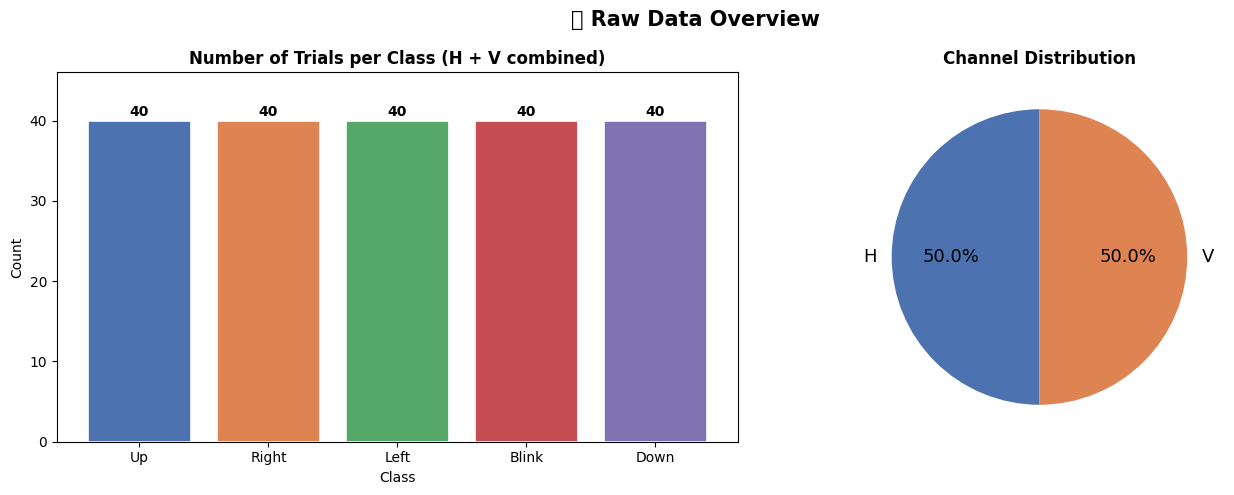

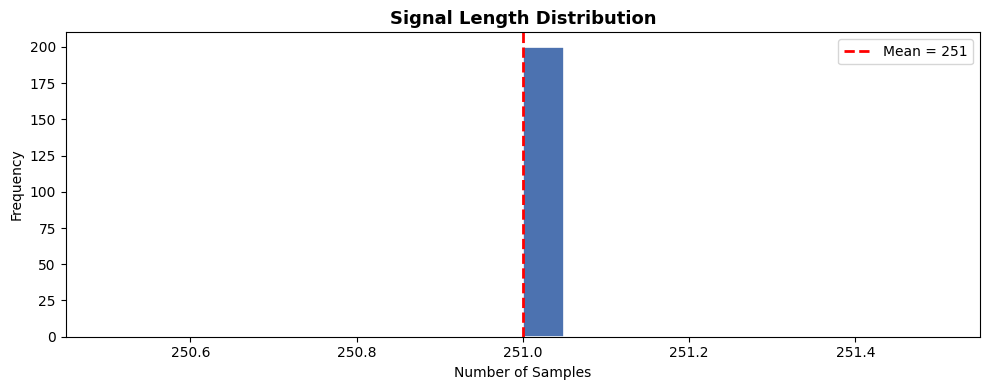

/tmp/ipykernel_5955/777942124.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5955/777942124.py:71: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_03_raw_signals.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


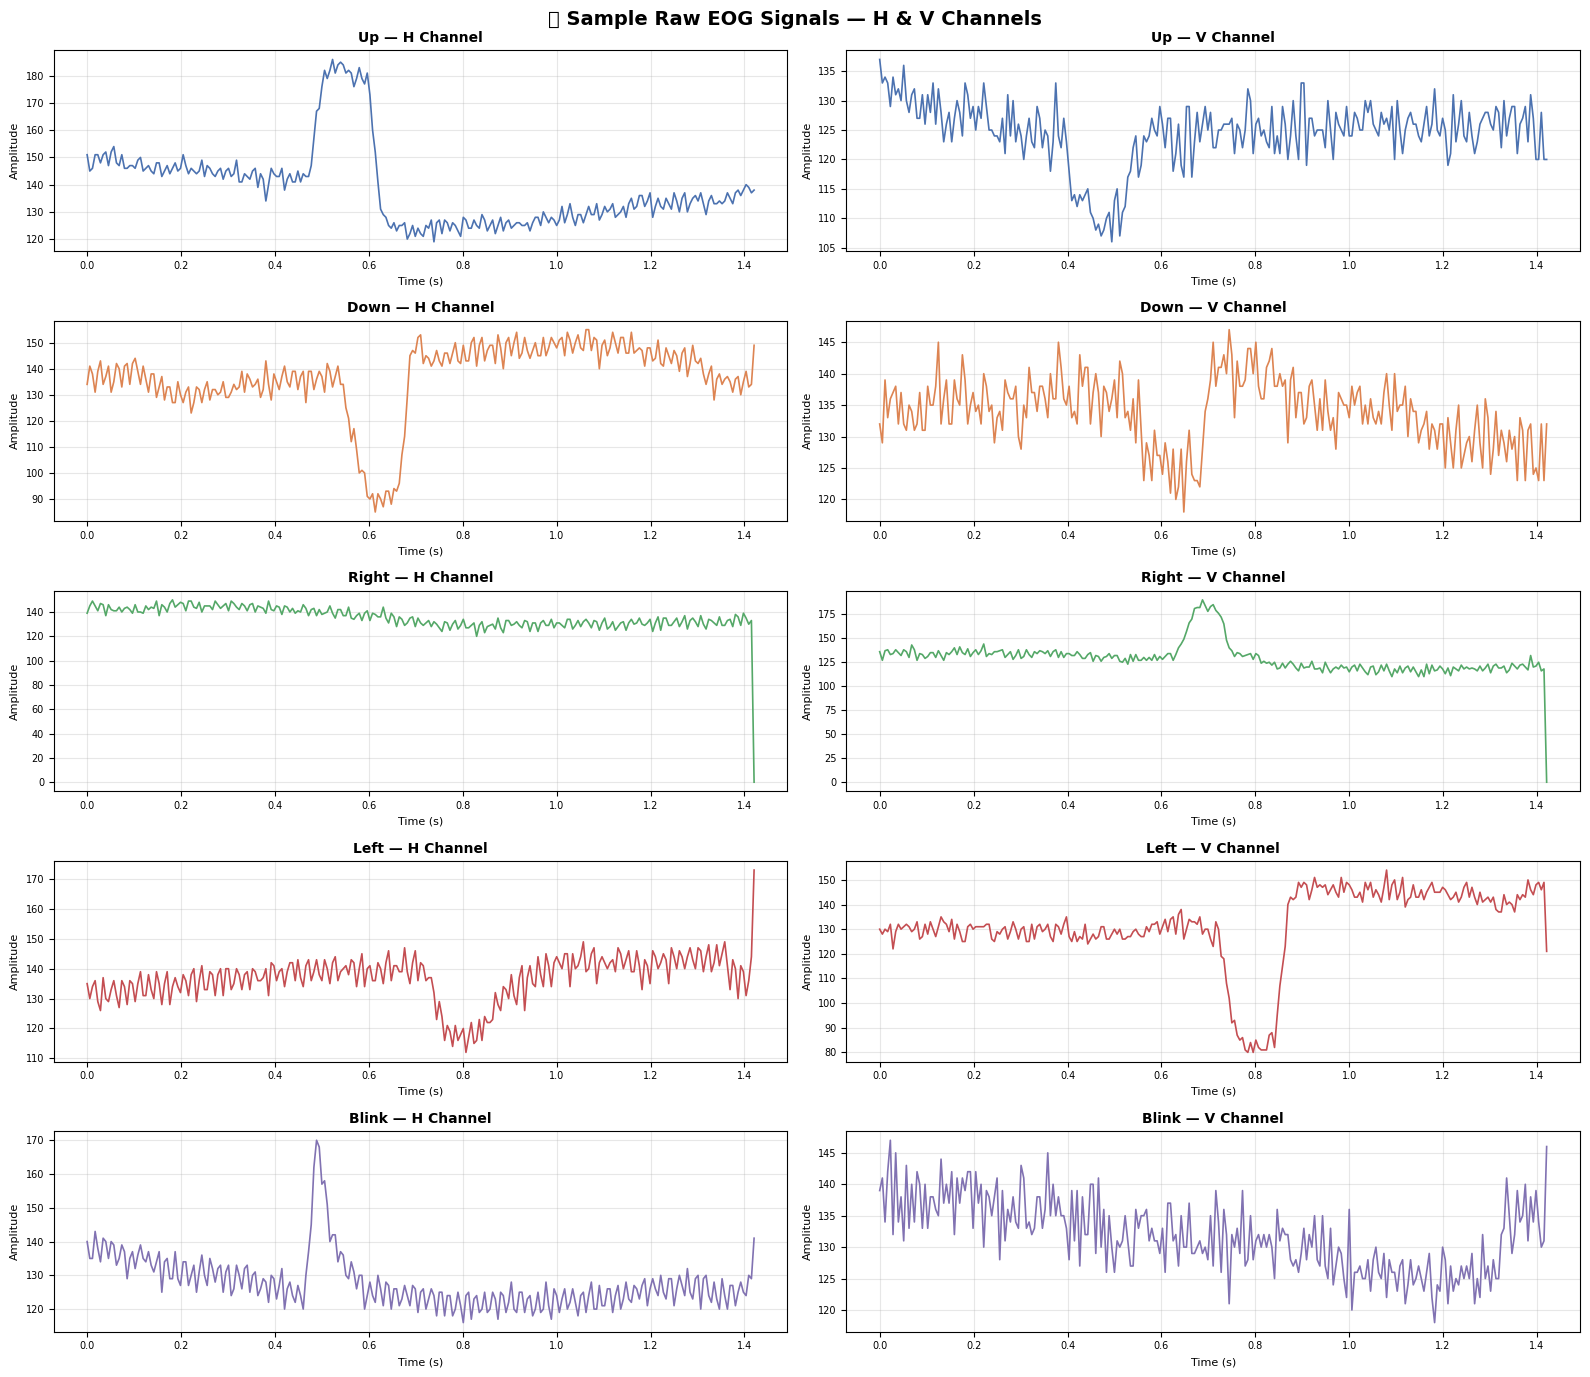

✅ VIZ CELL 1 done — Raw Data


In [31]:


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Raw Data Overview', fontsize=15, fontweight='bold')


class_counts = {}
for f in all_files:
    cls = f['class_label']
    class_counts[cls] = class_counts.get(cls, 0) + 1

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Number of Trials per Class (H + V combined)', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values()) * 1.15)


ch_counts = {'H': 0, 'V': 0}
for f in all_files:
    ch_counts[f['channel']] += 1
axes[1].pie(ch_counts.values(), labels=ch_counts.keys(), autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90, textprops={'fontsize':13})
axes[1].set_title('Channel Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_01_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))
lengths = [f['signal_length'] for f in all_files]
ax.hist(lengths, bins=20, color='#4C72B0', edgecolor='white', linewidth=1.2)
ax.axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(lengths):.0f}')
ax.set_title('Signal Length Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_02_signal_lengths.png'), dpi=150, bbox_inches='tight')
plt.show()


CLASS_NAMES_ORDERED = ['Up', 'Down', 'Right', 'Left', 'Blink']
colors_cls = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('📈 Sample Raw EOG Signals — H & V Channels', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES_ORDERED):
    for col_idx, ch in enumerate(['H', 'V']):
        sample = next((f for f in all_files if f['class_label'] == cls and f['channel'] == ch), None)
        ax = axes[row_idx][col_idx]
        if sample:
            t = np.arange(len(sample['signal'])) / FS
            ax.plot(t, sample['signal'], color=colors_cls[row_idx], linewidth=1.2)
            ax.set_title(f'{cls} — {ch} Channel', fontweight='bold', fontsize=10)
            ax.set_xlabel('Time (s)', fontsize=8)
            ax.set_ylabel('Amplitude', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_03_raw_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ VIZ CELL 1 done — Raw Data')

In [32]:
def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    """Butterworth bandpass filter"""
    nyq = fs / 2.0
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def apply_preprocessing(signal):
    """
    Apply only Bandpass Filtering
    """

    filtered_signal = bandpass_filter(
        signal,
        lowcut=BPF_LOW,
        highcut=BPF_HIGH,
        fs=FS,
        order=BPF_ORDER
    )

    return filtered_signal


/tmp/ipykernel_5955/4172637054.py:37: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5955/4172637054.py:38: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_04_preprocessing.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


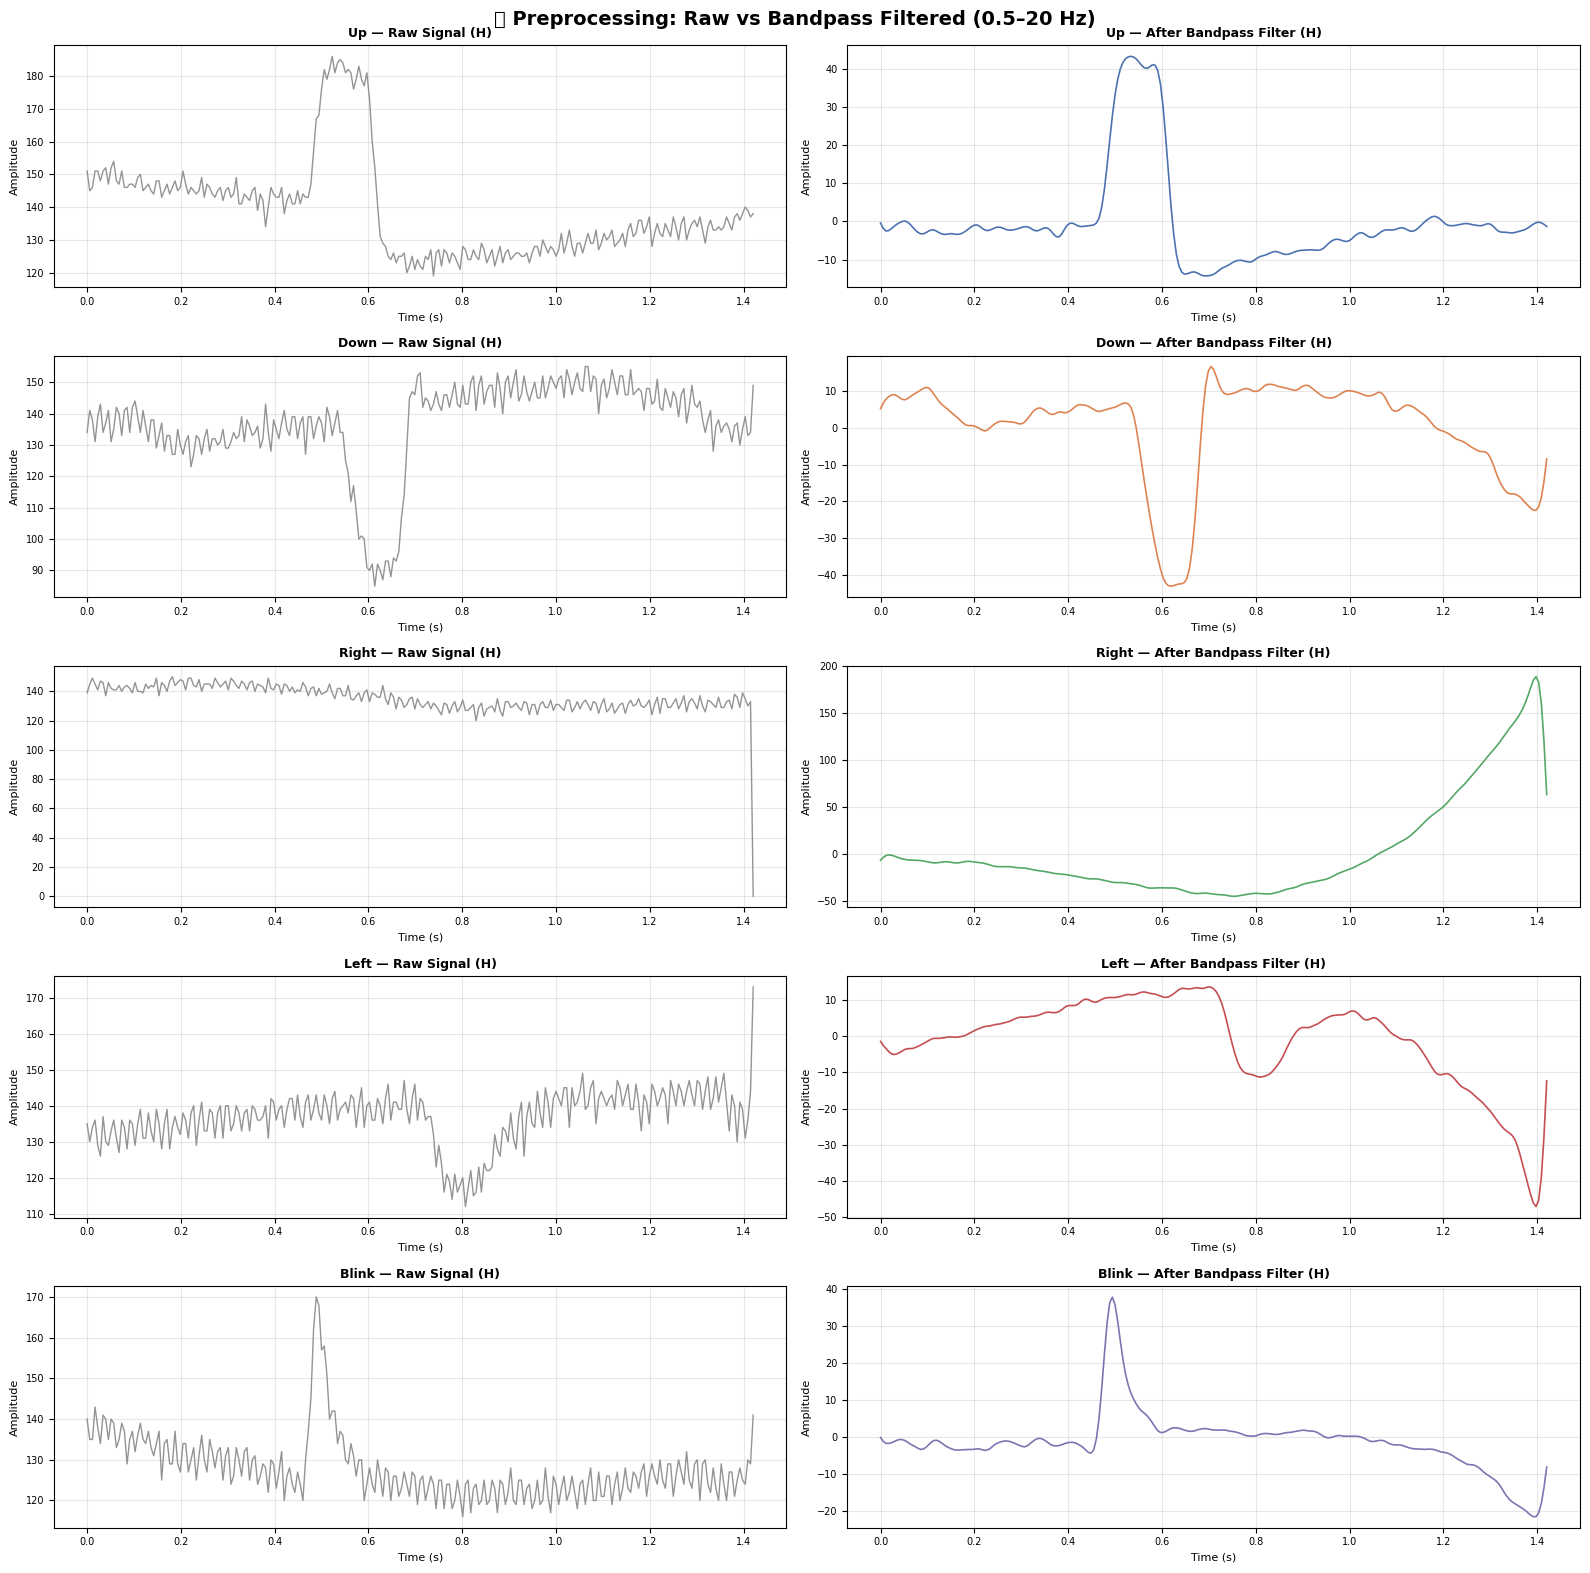

/tmp/ipykernel_5955/4172637054.py:74: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5955/4172637054.py:75: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_05_frequency_spectrum.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


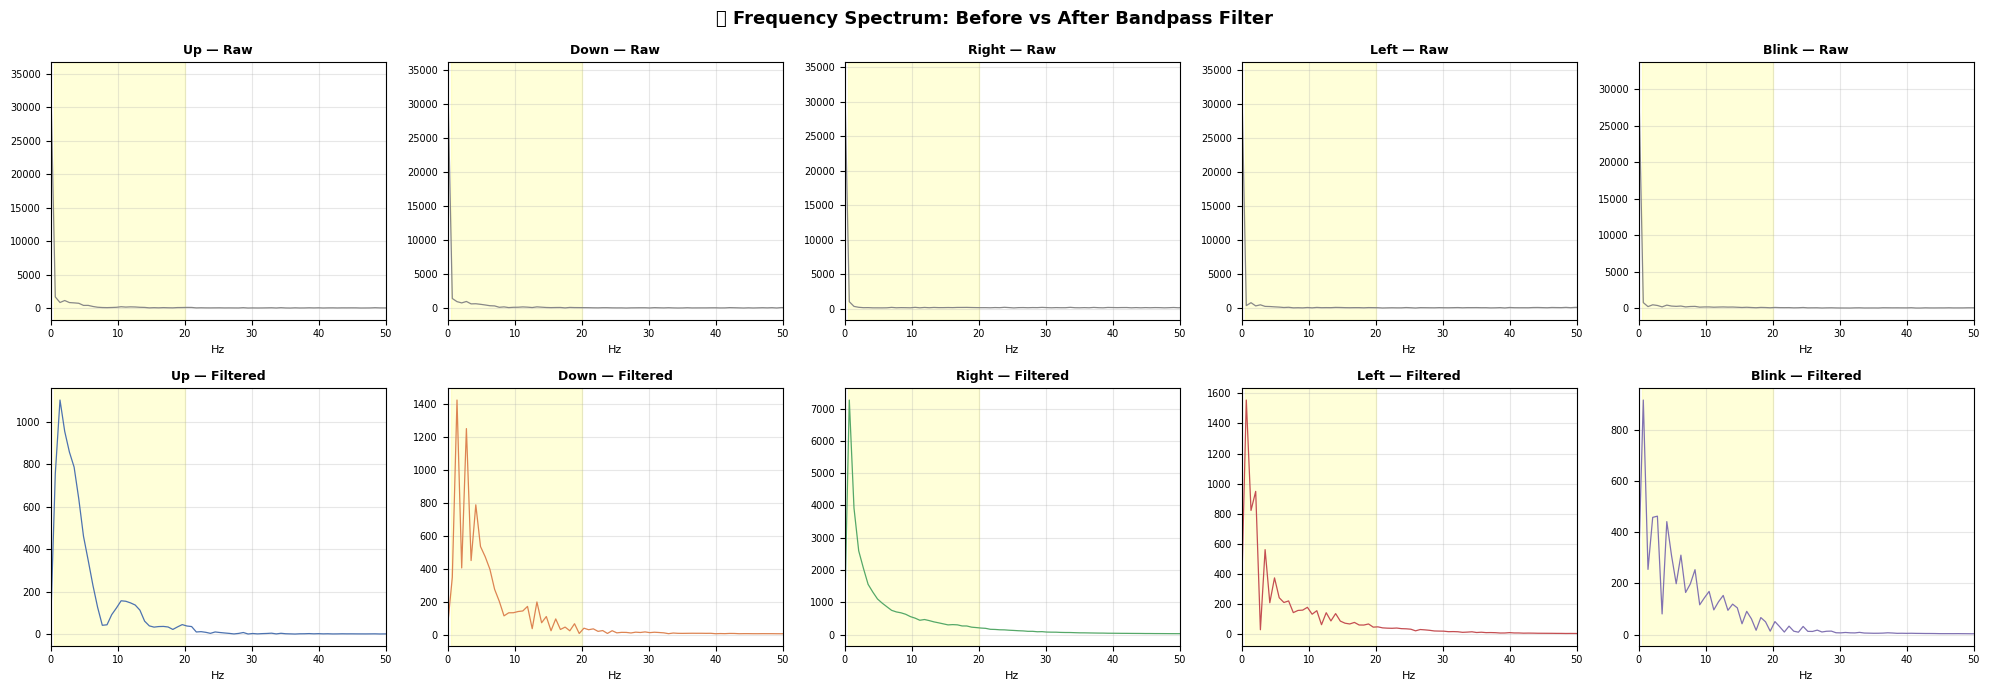

✅ VIZ CELL 2 done — Preprocessing


In [33]:


fig, axes = plt.subplots(5, 2, figsize=(16, 16))
fig.suptitle('🔧 Preprocessing: Raw vs Bandpass Filtered (0.5–20 Hz)', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES_ORDERED):
    sample = next((f for f in all_files if f['class_label'] == cls and f['channel'] == 'H'), None)
    if sample is None:
        continue

    raw    = sample['signal']
    filt   = apply_preprocessing(raw)
    t      = np.arange(len(raw)) / FS

    ax_raw  = axes[row_idx][0]
    ax_filt = axes[row_idx][1]

    ax_raw.plot(t, raw,  color='#888888', linewidth=1.0, alpha=0.9)
    ax_raw.set_title(f'{cls} — Raw Signal (H)', fontweight='bold', fontsize=9)
    ax_raw.set_ylabel('Amplitude', fontsize=8)
    ax_raw.set_xlabel('Time (s)', fontsize=8)
    ax_raw.tick_params(labelsize=7)
    ax_raw.grid(True, alpha=0.3)

    ax_filt.plot(t, filt, color=colors_cls[row_idx], linewidth=1.2)
    ax_filt.set_title(f'{cls} — After Bandpass Filter (H)', fontweight='bold', fontsize=9)
    ax_filt.set_ylabel('Amplitude', fontsize=8)
    ax_filt.set_xlabel('Time (s)', fontsize=8)
    ax_filt.tick_params(labelsize=7)
    ax_filt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_04_preprocessing.png'), dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('🔊 Frequency Spectrum: Before vs After Bandpass Filter', fontsize=13, fontweight='bold')

for col_idx, cls in enumerate(CLASS_NAMES_ORDERED):
    sample = next((f for f in all_files if f['class_label'] == cls and f['channel'] == 'H'), None)
    if sample is None:
        continue

    raw  = sample['signal']
    filt = apply_preprocessing(raw)
    n    = len(raw)
    freq = np.fft.rfftfreq(n, d=1.0/FS)

    fft_raw  = np.abs(np.fft.rfft(raw))
    fft_filt = np.abs(np.fft.rfft(filt))

    axes[0][col_idx].plot(freq, fft_raw,  color='#888888', linewidth=0.9)
    axes[0][col_idx].set_title(f'{cls} — Raw', fontsize=9, fontweight='bold')
    axes[0][col_idx].set_xlim(0, 50)
    axes[0][col_idx].set_xlabel('Hz', fontsize=8)
    axes[0][col_idx].tick_params(labelsize=7)
    axes[0][col_idx].grid(True, alpha=0.3)
    axes[0][col_idx].axvspan(0.5, 20, color='yellow', alpha=0.15)

    axes[1][col_idx].plot(freq, fft_filt, color=colors_cls[col_idx], linewidth=0.9)
    axes[1][col_idx].set_title(f'{cls} — Filtered', fontsize=9, fontweight='bold')
    axes[1][col_idx].set_xlim(0, 50)
    axes[1][col_idx].set_xlabel('Hz', fontsize=8)
    axes[1][col_idx].tick_params(labelsize=7)
    axes[1][col_idx].grid(True, alpha=0.3)
    axes[1][col_idx].axvspan(0.5, 20, color='yellow', alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_05_frequency_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ VIZ CELL 2 done — Preprocessing')



In [34]:
def extract_dwt_features(signal, wavelet='db4', level=2):

    coeffs = pywt.wavedec(signal, wavelet, level=level)
    cA2 = coeffs[0]
    return cA2

# def extract_ar_features(signal, lags=2):

#     model = AutoReg(signal, lags=lags).fit()

#     ar1 = model.params[0]
#     ar2 = model.params[1]
#     ar3 = model.params[2]

#     return ar1, ar2, ar3


def extract_ar_features(signal, lags=AR_LAGS):

    model = AutoReg(signal, lags=lags).fit()

    return model.params

/tmp/ipykernel_5955/2438346779.py:31: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5955/2438346779.py:32: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_06_dwt_decomposition.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


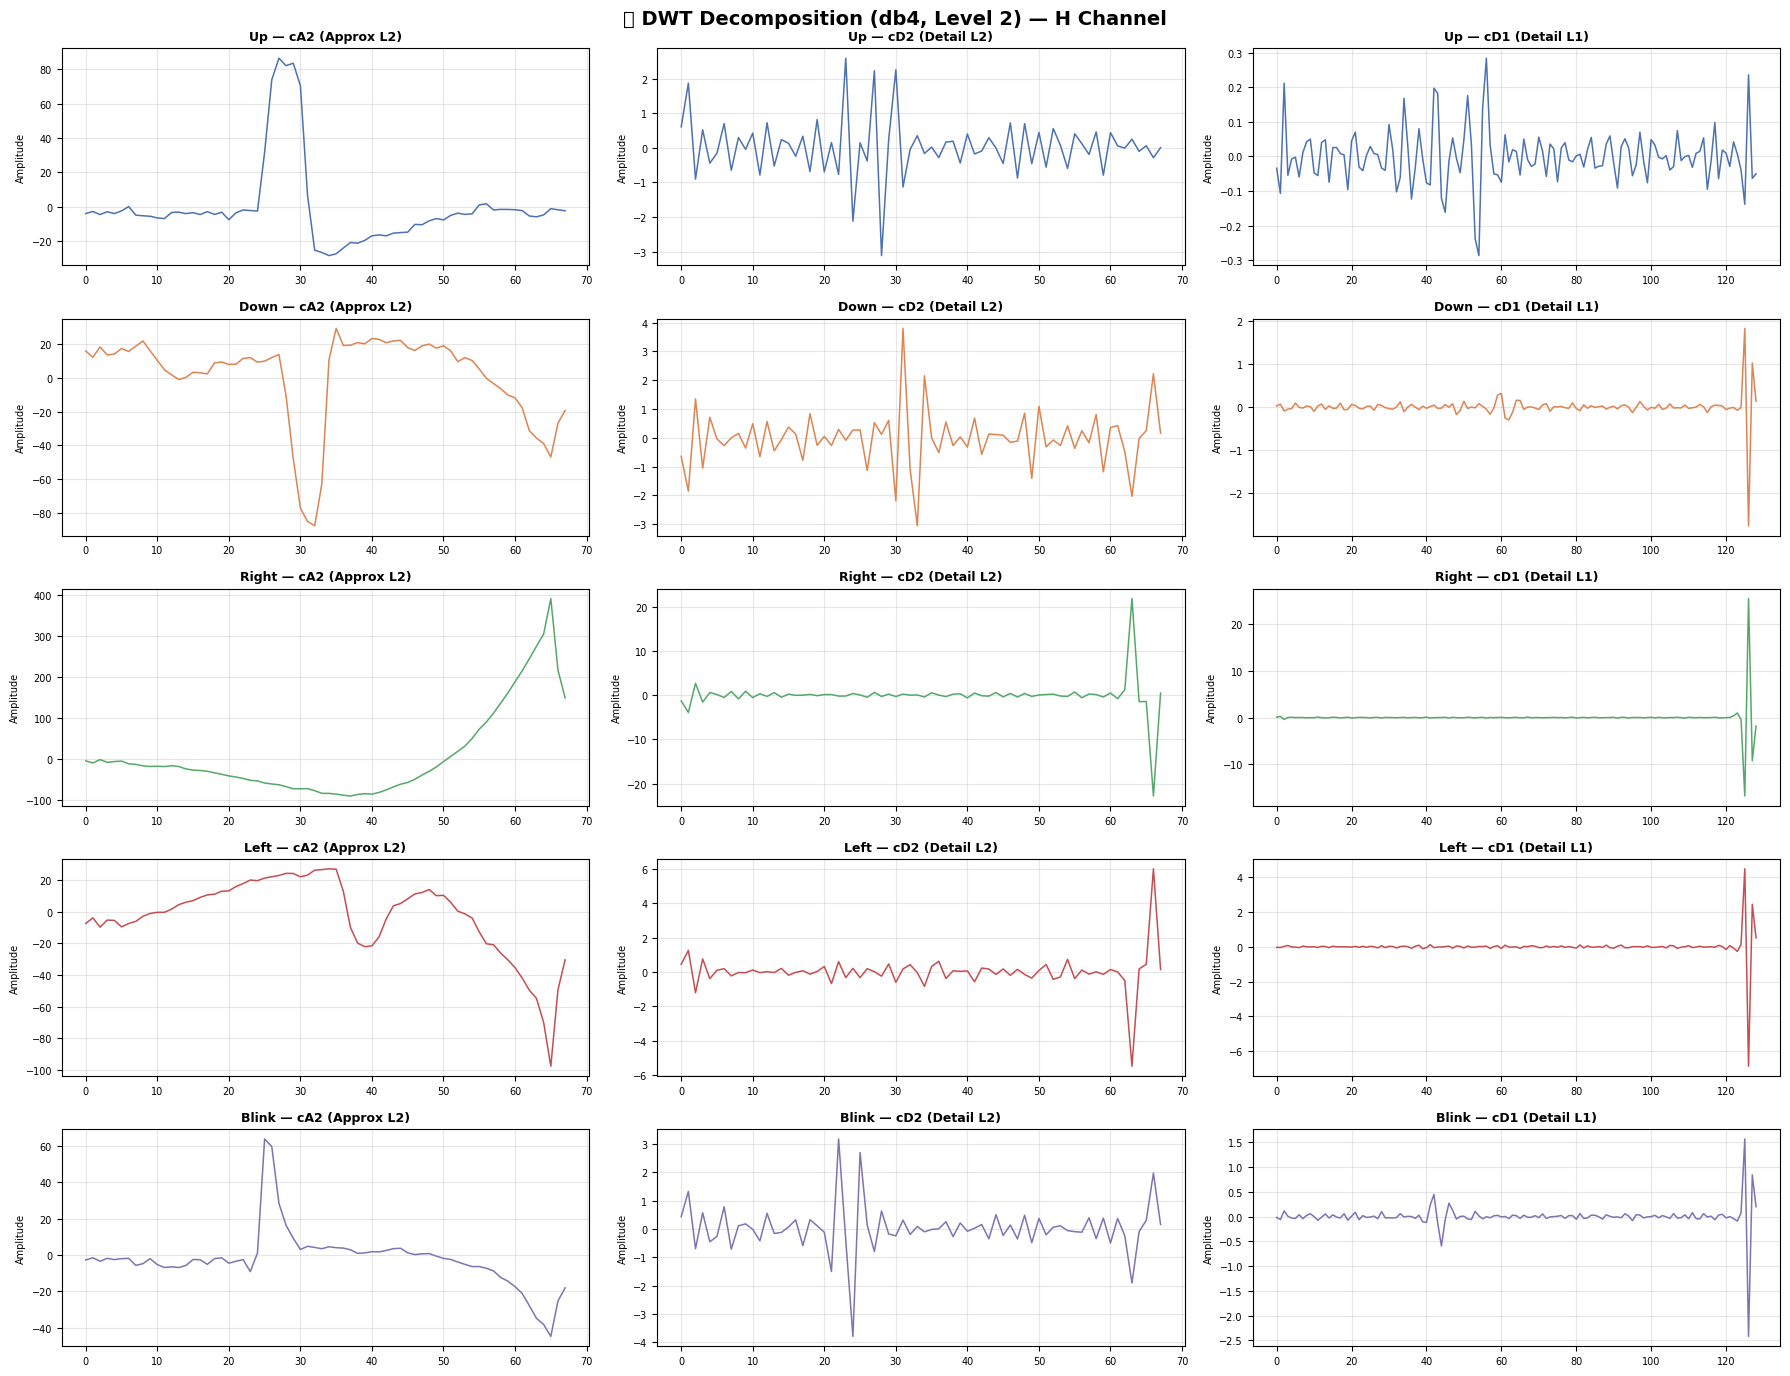

✅ VIZ CELL 3 done — DWT


In [35]:

import pywt

fig, axes = plt.subplots(5, 3, figsize=(18, 14))
fig.suptitle('🌊 DWT Decomposition (db4, Level 2) — H Channel', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES_ORDERED):
    sample = next((f for f in all_files if f['class_label'] == cls and f['channel'] == 'H'), None)
    if sample is None:
        continue

    sig    = apply_preprocessing(sample['signal'])
    coeffs = pywt.wavedec(sig, DWT_WAVELET, level=DWT_LEVEL)


    labels = ['cA2 (Approx L2)', 'cD2 (Detail L2)', 'cD1 (Detail L1)']
    for col_idx, (coeff, lbl) in enumerate(zip(coeffs, labels)):
        ax = axes[row_idx][col_idx]
        ax.plot(coeff, color=colors_cls[row_idx], linewidth=1.1)
        ax.set_title(f'{cls} — {lbl}', fontsize=9, fontweight='bold')
        ax.set_ylabel('Amplitude', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'viz_06_dwt_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ VIZ CELL 3 done — DWT')

In [37]:
from sklearn.ensemble              import (RandomForestClassifier,
                                           ExtraTreesClassifier,
                                           GradientBoostingClassifier,
                                           VotingClassifier)
from sklearn.neighbors             import KNeighborsClassifier
from sklearn.pipeline              import Pipeline
import warnings
warnings.filterwarnings('ignore')


def save_features_to_excel(X, y, save_path):

    df = pd.DataFrame(X)

    df['label'] = y

    df.to_excel(save_path, index=False)

    print(f' Saved: {save_path}')

def get_signal_from_row(row):

    signal_cols = [c for c in row.index if c.startswith('signal_')]

    signal = row[signal_cols].values.astype(float)

    return signal


# --------------------------------
# Extract Features
# --------------------------------

def extract_features(signal, feature_type):

    if '+' in feature_type:
        parts = feature_type.split('+')
        return np.concatenate([extract_features(signal, p) for p in parts])


    filtered = apply_preprocessing(signal)




    if feature_type == 'raw':

        features = filtered

    elif feature_type == 'dwt':

        features = extract_dwt_features(
            filtered,
            wavelet=DWT_WAVELET,
            level=DWT_LEVEL
        )

    elif feature_type == 'ar':

        features = np.array(
            extract_ar_features(filtered)
        )

    else:
        raise ValueError(f"Unknown feature_type: '{feature_type}'")

    return features



def build_feature_dataset(df_h, df_v, feature_type='raw'):

    X = []
    y = []

    for i in range(len(df_h)):


        row_h = df_h.iloc[i]

        signal_h = get_signal_from_row(row_h)

        feat_h = extract_features(
            signal_h,
            feature_type
        )



        row_v = df_v.iloc[i]

        signal_v = get_signal_from_row(row_v)

        feat_v = extract_features(
            signal_v,
            feature_type
        )


        combined_features = np.concatenate([
            feat_h,
            feat_v
        ])

        X.append(combined_features)

        y.append(row_h['class_label'])

    return np.array(X), np.array(y)


def process_round(round_num, feature_type):


    train_h = pd.read_excel(
        os.path.join(
            OUTPUT_FOLDER,
            f'Round{round_num}_Train_H.xlsx'
        )
    )

    train_v = pd.read_excel(
        os.path.join(
            OUTPUT_FOLDER,
            f'Round{round_num}_Train_V.xlsx'
        )
    )

    test_h = pd.read_excel(
        os.path.join(
            OUTPUT_FOLDER,
            f'Round{round_num}_Test_H.xlsx'
        )
    )

    test_v = pd.read_excel(
        os.path.join(
            OUTPUT_FOLDER,
            f'Round{round_num}_Test_V.xlsx'
        )
    )



    X_train, y_train = build_feature_dataset(
        train_h,
        train_v,
        feature_type
    )

    X_test, y_test = build_feature_dataset(
        test_h,
        test_v,
        feature_type
    )


    feature_folder = os.path.join(
        OUTPUT_FOLDER,
        'Extracted_Features'
    )

    os.makedirs(feature_folder, exist_ok=True)

    train_save_path = os.path.join(
        feature_folder,
        f'Round{round_num}_Train_{feature_type}.xlsx'
    )

    test_save_path = os.path.join(
        feature_folder,
        f'Round{round_num}_Test_{feature_type}.xlsx'
    )

    save_features_to_excel(
        X_train,
        y_train,
        train_save_path
    )

    save_features_to_excel(
        X_test,
        y_test,
        test_save_path
    )

    return X_train, y_train, X_test, y_test


def process_round_combined(round_num, feature_type):
    """Identical to process_round but works for combined feature types too."""
    return process_round(round_num, feature_type)


lag_min = 4  (أقصر دورة مفيدة في السيجنال)
lag_max = 10  (مبني على FS/10 وحجم الداتا)
Testing lags: 4 → 10

  Lag |     R1     R2     R3     R4 |    Mean    Std
-------------------------------------------------------
    4 |   68.0   84.0   76.0   52.0 |   70.0%  11.8%
    5 |   84.0   96.0   84.0   72.0 |   84.0%   8.5%
    6 |   84.0   96.0   88.0   72.0 |   85.0%   8.7%
    7 |   80.0   88.0   72.0   60.0 |   75.0%  10.3%
    8 |   80.0   88.0   76.0   72.0 |   79.0%   5.9%
    9 |   76.0   88.0   76.0   84.0 |   81.0%   5.2%
   10 |   76.0   68.0   72.0   80.0 |   74.0%   4.5%

✅ Best lag = 6 → 85.0% ± 8.7%
✅ AR_LAGS updated to 6 — الـ training loop هيستخدمه تلقائياً


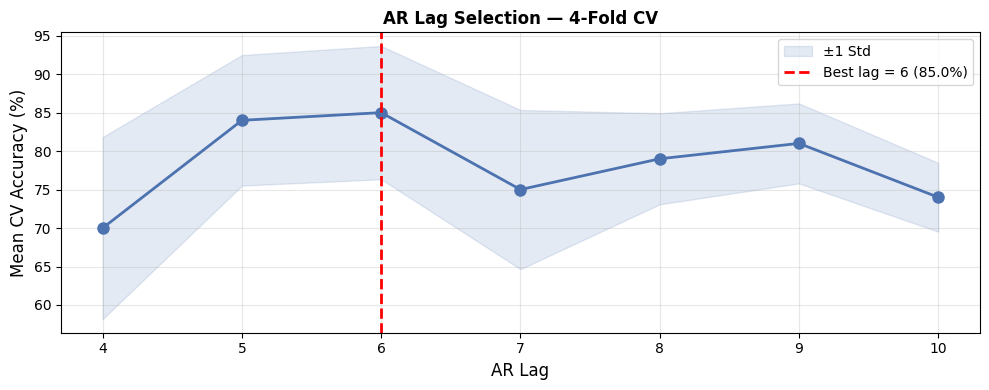

In [40]:

lag_min         = 4
lag_max         = 10
lag_range       = range(4, lag_max + 1)

print(f"lag_min = {lag_min}  (أقصر دورة مفيدة في السيجنال)")
print(f"lag_max = {lag_max}  (مبني على FS/10 وحجم الداتا)")
print(f"Testing lags: {lag_min} → {lag_max}\n")

lag_results = {}

print(f"{'Lag':>5} | {'R1':>6} {'R2':>6} {'R3':>6} {'R4':>6} | {'Mean':>7} {'Std':>6}")
print("-" * 55)

for lag in lag_range:
    fold_accs = []

    for fold in FOLDS:
        r = fold['round']
        train_h = pd.read_excel(os.path.join(OUTPUT_FOLDER, f'Round{r}_Train_H.xlsx'))
        train_v = pd.read_excel(os.path.join(OUTPUT_FOLDER, f'Round{r}_Train_V.xlsx'))
        test_h  = pd.read_excel(os.path.join(OUTPUT_FOLDER, f'Round{r}_Test_H.xlsx'))
        test_v  = pd.read_excel(os.path.join(OUTPUT_FOLDER, f'Round{r}_Test_V.xlsx'))

        def get_ar(df_h, df_v, lag):
            X, y = [], []
            for i in range(len(df_h)):
                sig_h = apply_preprocessing(get_signal_from_row(df_h.iloc[i]))
                sig_v = apply_preprocessing(get_signal_from_row(df_v.iloc[i]))
                ar_h  = AutoReg(sig_h, lags=lag).fit().params
                ar_v  = AutoReg(sig_v, lags=lag).fit().params
                X.append(np.concatenate([ar_h, ar_v]))
                y.append(df_h.iloc[i]['class_label'])
            return np.array(X), np.array(y)

        X_train, y_train = get_ar(train_h, train_v, lag)
        X_test,  y_test  = get_ar(test_h,  test_v,  lag)

        scaler = StandardScaler()
        clf    = SVC(kernel='rbf', C=10, gamma='scale')
        clf.fit(scaler.fit_transform(X_train), y_train)
        acc    = accuracy_score(y_test, clf.predict(scaler.transform(X_test))) * 100
        fold_accs.append(acc)

    lag_results[lag] = {'mean': np.mean(fold_accs), 'std': np.std(fold_accs)}
    print(f"{lag:>5} | {fold_accs[0]:>6.1f} {fold_accs[1]:>6.1f} "
          f"{fold_accs[2]:>6.1f} {fold_accs[3]:>6.1f} | "
          f"{np.mean(fold_accs):>6.1f}% {np.std(fold_accs):>5.1f}%")

best_lag = max(lag_results, key=lambda k: lag_results[k]['mean'])
AR_LAGS  = best_lag

print(f"\n✅ Best lag = {best_lag} → {lag_results[best_lag]['mean']:.1f}% ± {lag_results[best_lag]['std']:.1f}%")


fig, ax = plt.subplots(figsize=(10, 4))
means = [lag_results[l]['mean'] for l in lag_range]
stds  = [lag_results[l]['std']  for l in lag_range]

ax.plot(list(lag_range), means, 'o-', color='#4C72B0', linewidth=2, markersize=8)
ax.fill_between(list(lag_range),
                [m-s for m,s in zip(means,stds)],
                [m+s for m,s in zip(means,stds)],
                alpha=0.15, color='#4C72B0', label='±1 Std')
ax.axvline(best_lag, color='red', linestyle='--', linewidth=2,
           label=f'Best lag = {best_lag} ({lag_results[best_lag]["mean"]:.1f}%)')
ax.set_xlabel('AR Lag', fontsize=12)
ax.set_ylabel('Mean CV Accuracy (%)', fontsize=12)
ax.set_title('AR Lag Selection — 4-Fold CV', fontsize=12, fontweight='bold')
ax.set_xticks(list(lag_range))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'ar_lag_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import warnings, time
warnings.filterwarnings('ignore')

feature_types = ['raw', 'ar', 'dwt', 'raw+ar', 'raw+dwt', 'ar+dwt', 'raw+ar+dwt']
NEEDS_SCALING = {'SVM'}
CLASS_NAMES   = ['Up', 'Down', 'Right', 'Left', 'Blink']

param_sets = {

    'SVM': [
        {'kernel': 'rbf',    'C': 5,   'gamma': 'scale'},
        {'kernel': 'rbf',    'C': 10,  'gamma': 'scale'},
        {'kernel': 'rbf',    'C': 50,  'gamma': 0.001 },
        {'kernel': 'rbf',    'C': 100, 'gamma': 0.001 },
        {'kernel': 'rbf',    'C': 1,   'gamma': 0.01  },
        {'kernel': 'linear', 'C': 0.1                 },
        {'kernel': 'linear', 'C': 1                   },
        {'kernel': 'linear', 'C': 10                  },
    ],

    'RF': [
        {'criterion': 'gini',    'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300},
        {'criterion': 'gini',    'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300},
        {'criterion': 'gini',    'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300},
        {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200},
    ],

    'GradBoost': [
        {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None,   'n_estimators': 100, 'subsample': 0.8},
        {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 200, 'subsample': 0.8},
        {'learning_rate': 0.1,  'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 0.8},
        {'learning_rate': 0.1,  'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 0.8},
    ],
}

model_classes = {
    'SVM'      : SVC,
    'RF'       : RandomForestClassifier,
    'GradBoost': GradientBoostingClassifier,
}

results_mean    = {}
results_std     = {}
best_params_log = {}
fold_details    = {}

DIVIDER  = '=' * 65
DIVIDER2 = '-' * 45


total_start = time.time()

for feature_type in feature_types:

    print(f'\n{DIVIDER}')
    print(f'  FEATURE TYPE : {feature_type.upper()}')
    print(f'{DIVIDER}')

    best_params_log[feature_type] = {}
    fold_details[feature_type]    = {}

    for model_name in param_sets:

        print(f'\n  MODEL : {model_name}')
        print(f'  Testing {len(param_sets[model_name])} parameter sets...')
        t0 = time.time()

        best_mean         = -1
        best_params       = None
        best_fold_records = []
        best_accs         = []


        for params in param_sets[model_name]:

            accs         = []
            fold_records = []

            for fold in FOLDS:

                r = fold['round']

                X_train, y_train, X_test, y_test = process_round(r, feature_type)

                if model_name in NEEDS_SCALING:
                    scaler      = StandardScaler()
                    X_train_fit = scaler.fit_transform(X_train)
                    X_test_fit  = scaler.transform(X_test)
                else:
                    X_train_fit = X_train
                    X_test_fit  = X_test


                if model_name == 'SVM':
                    clf = model_classes[model_name](**params)
                elif model_name == 'RF':
                    clf = model_classes[model_name](**params, random_state=42, n_jobs=-1)
                elif model_name == 'GradBoost':
                    clf = model_classes[model_name](**params, random_state=42)

                clf.fit(X_train_fit, y_train)
                y_pred = clf.predict(X_test_fit)
                acc    = accuracy_score(y_test, y_pred) * 100
                accs.append(acc)

                fold_records.append({
                    'round'     : r,
                    'acc'       : acc,
                    'params'    : params,
                    'y_test'    : y_test,
                    'y_pred'    : y_pred,
                    'train_size': len(y_train),
                    'test_size' : len(y_test),
                })

            mean_acc = np.mean(accs)
            if mean_acc > best_mean:
                best_mean         = mean_acc
                best_params       = params
                best_fold_records = fold_records
                best_accs         = accs


        std_acc = np.std(best_accs)
        key     = f'{feature_type}_{model_name}'

        results_mean[key]                         = best_mean
        results_std[key]                          = std_acc
        best_params_log[feature_type][model_name] = best_params
        fold_details[feature_type][model_name]    = best_fold_records

        elapsed = time.time() - t0


        print(f'\n  Best params : {best_params}')
        for rec in best_fold_records:
            print(f'  Round {rec["round"]}/{len(FOLDS)} ... acc = {rec["acc"]:.1f}%')
        print(f'  Mean = {best_mean:.2f}% +/- {std_acc:.2f}%   ({elapsed:.1f}s)')


        print(f'\n  Per-class results per round:')
        print(f'  {"Class":<10} {"Round":>7} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
        print(f'  {"-"*52}')

        all_reports = []
        for rec in best_fold_records:
            rep = classification_report(
                rec['y_test'], rec['y_pred'],
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0
            )
            all_reports.append(rep)
            for cls in CLASS_NAMES:
                p  = rep[cls]['precision'] * 100
                rc = rep[cls]['recall']    * 100
                f1 = rep[cls]['f1-score']  * 100
                print(f'  {cls:<10} {rec["round"]:>7}   {p:>9.1f}% {rc:>9.1f}% {f1:>9.1f}%')
            print()


        print(f'  {"Class":<10} {"AVG":>7} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
        print(f'  {"-"*52}')
        for cls in CLASS_NAMES:
            p  = np.mean([r[cls]['precision'] for r in all_reports]) * 100
            rc = np.mean([r[cls]['recall']    for r in all_reports]) * 100
            f1 = np.mean([r[cls]['f1-score']  for r in all_reports]) * 100
            print(f'  {cls:<10} {"avg":>7}   {p:>9.1f}% {rc:>9.1f}% {f1:>9.1f}%')

total_elapsed = time.time() - total_start
print(f'\n{DIVIDER}')
print(f'  All models done in {total_elapsed/60:.1f} min')
print(f'{DIVIDER}')


print(f'\n{DIVIDER}')
print(f'  RESULTS SUMMARY')
print(f'{DIVIDER}')
print(f'  {"Feature":<8} {"Model":<14} {"R1":>6} {"R2":>6} {"R3":>6} {"R4":>6}   {"Mean":>7} {"Std":>6}')
print(f'  {DIVIDER2}')

sorted_keys = sorted(results_mean.keys(), key=lambda k: results_mean[k], reverse=True)

for key in sorted_keys:
    ft, mn = key.split('_', 1)
    recs   = fold_details[ft][mn]
    accs   = [r['acc'] for r in recs]
    prefix = '*' if results_mean[key] == max(results_mean.values()) else ' '
    print(f'{prefix} {ft.upper():<8} {mn:<14}',
          ' '.join([f'{a:>6.1f}' for a in accs]),
          f'  {results_mean[key]:>6.2f}%  +/-{results_std[key]:.2f}%')

print(f'  {DIVIDER2}')
best_key         = max(results_mean, key=results_mean.get)
best_ft, best_mn = best_key.split('_', 1)
print(f'  BEST: {best_mn} + {best_ft.upper()} -> '
      f'{results_mean[best_key]:.2f}% +/- {results_std[best_key]:.2f}%')
print(f'{DIVIDER}')


  FEATURE TYPE : RAW

  MODEL : SVM
  Testing 8 parameter sets...
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round3_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round3_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round4_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round4_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Train_raw.xlsx
 Saved: /content/drive/My

       Feature      Model  Mean Accuracy (%)  Std (%)
0          RAW        SVM               95.0     4.36
1       RAW+AR        SVM               95.0     4.36
2   RAW+AR+DWT        SVM               95.0     4.36
3      RAW+DWT        SVM               95.0     4.36
4       AR+DWT        SVM               94.0     4.47
5          DWT        SVM               93.0     5.92
6       AR+DWT         RF               92.0     4.90
7       AR+DWT  GradBoost               91.0     5.92
8          RAW  GradBoost               90.0     7.21
9           AR        SVM               90.0     6.00
10     RAW+DWT         RF               90.0     7.21
11         DWT  GradBoost               89.0    10.34
12         RAW         RF               89.0     8.66
13  RAW+AR+DWT  GradBoost               89.0     7.14
14  RAW+AR+DWT         RF               89.0     8.66
15      RAW+AR  GradBoost               89.0     7.68
16         DWT         RF               88.0     8.94
17     RAW+DWT  GradBoost   

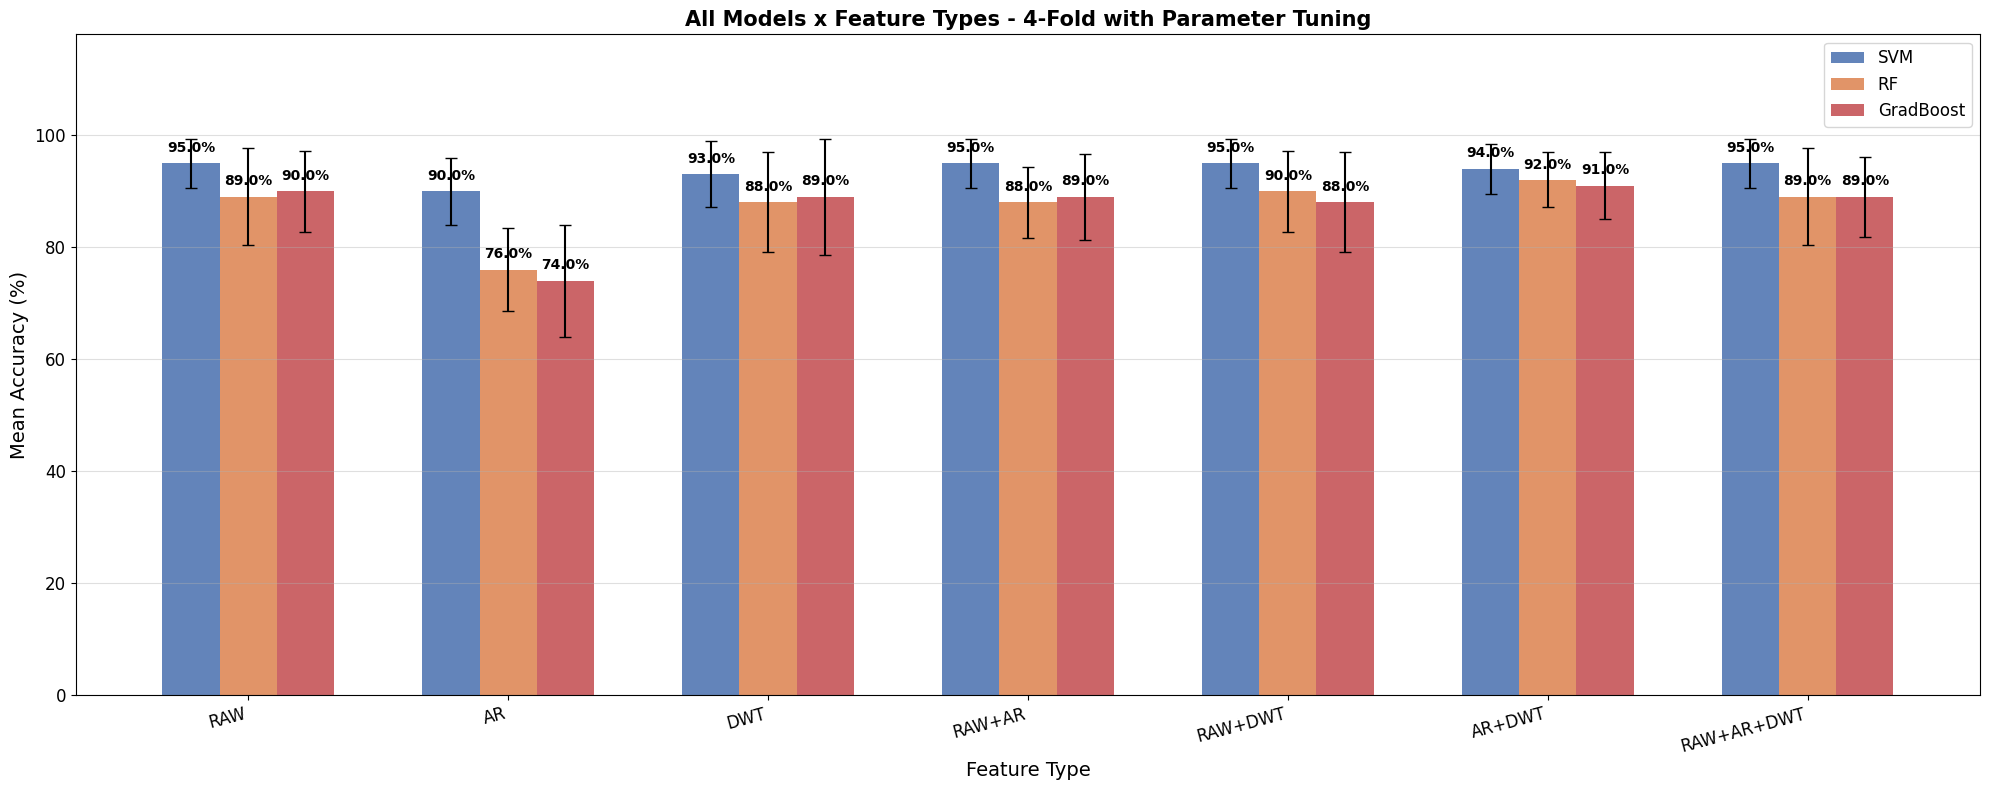

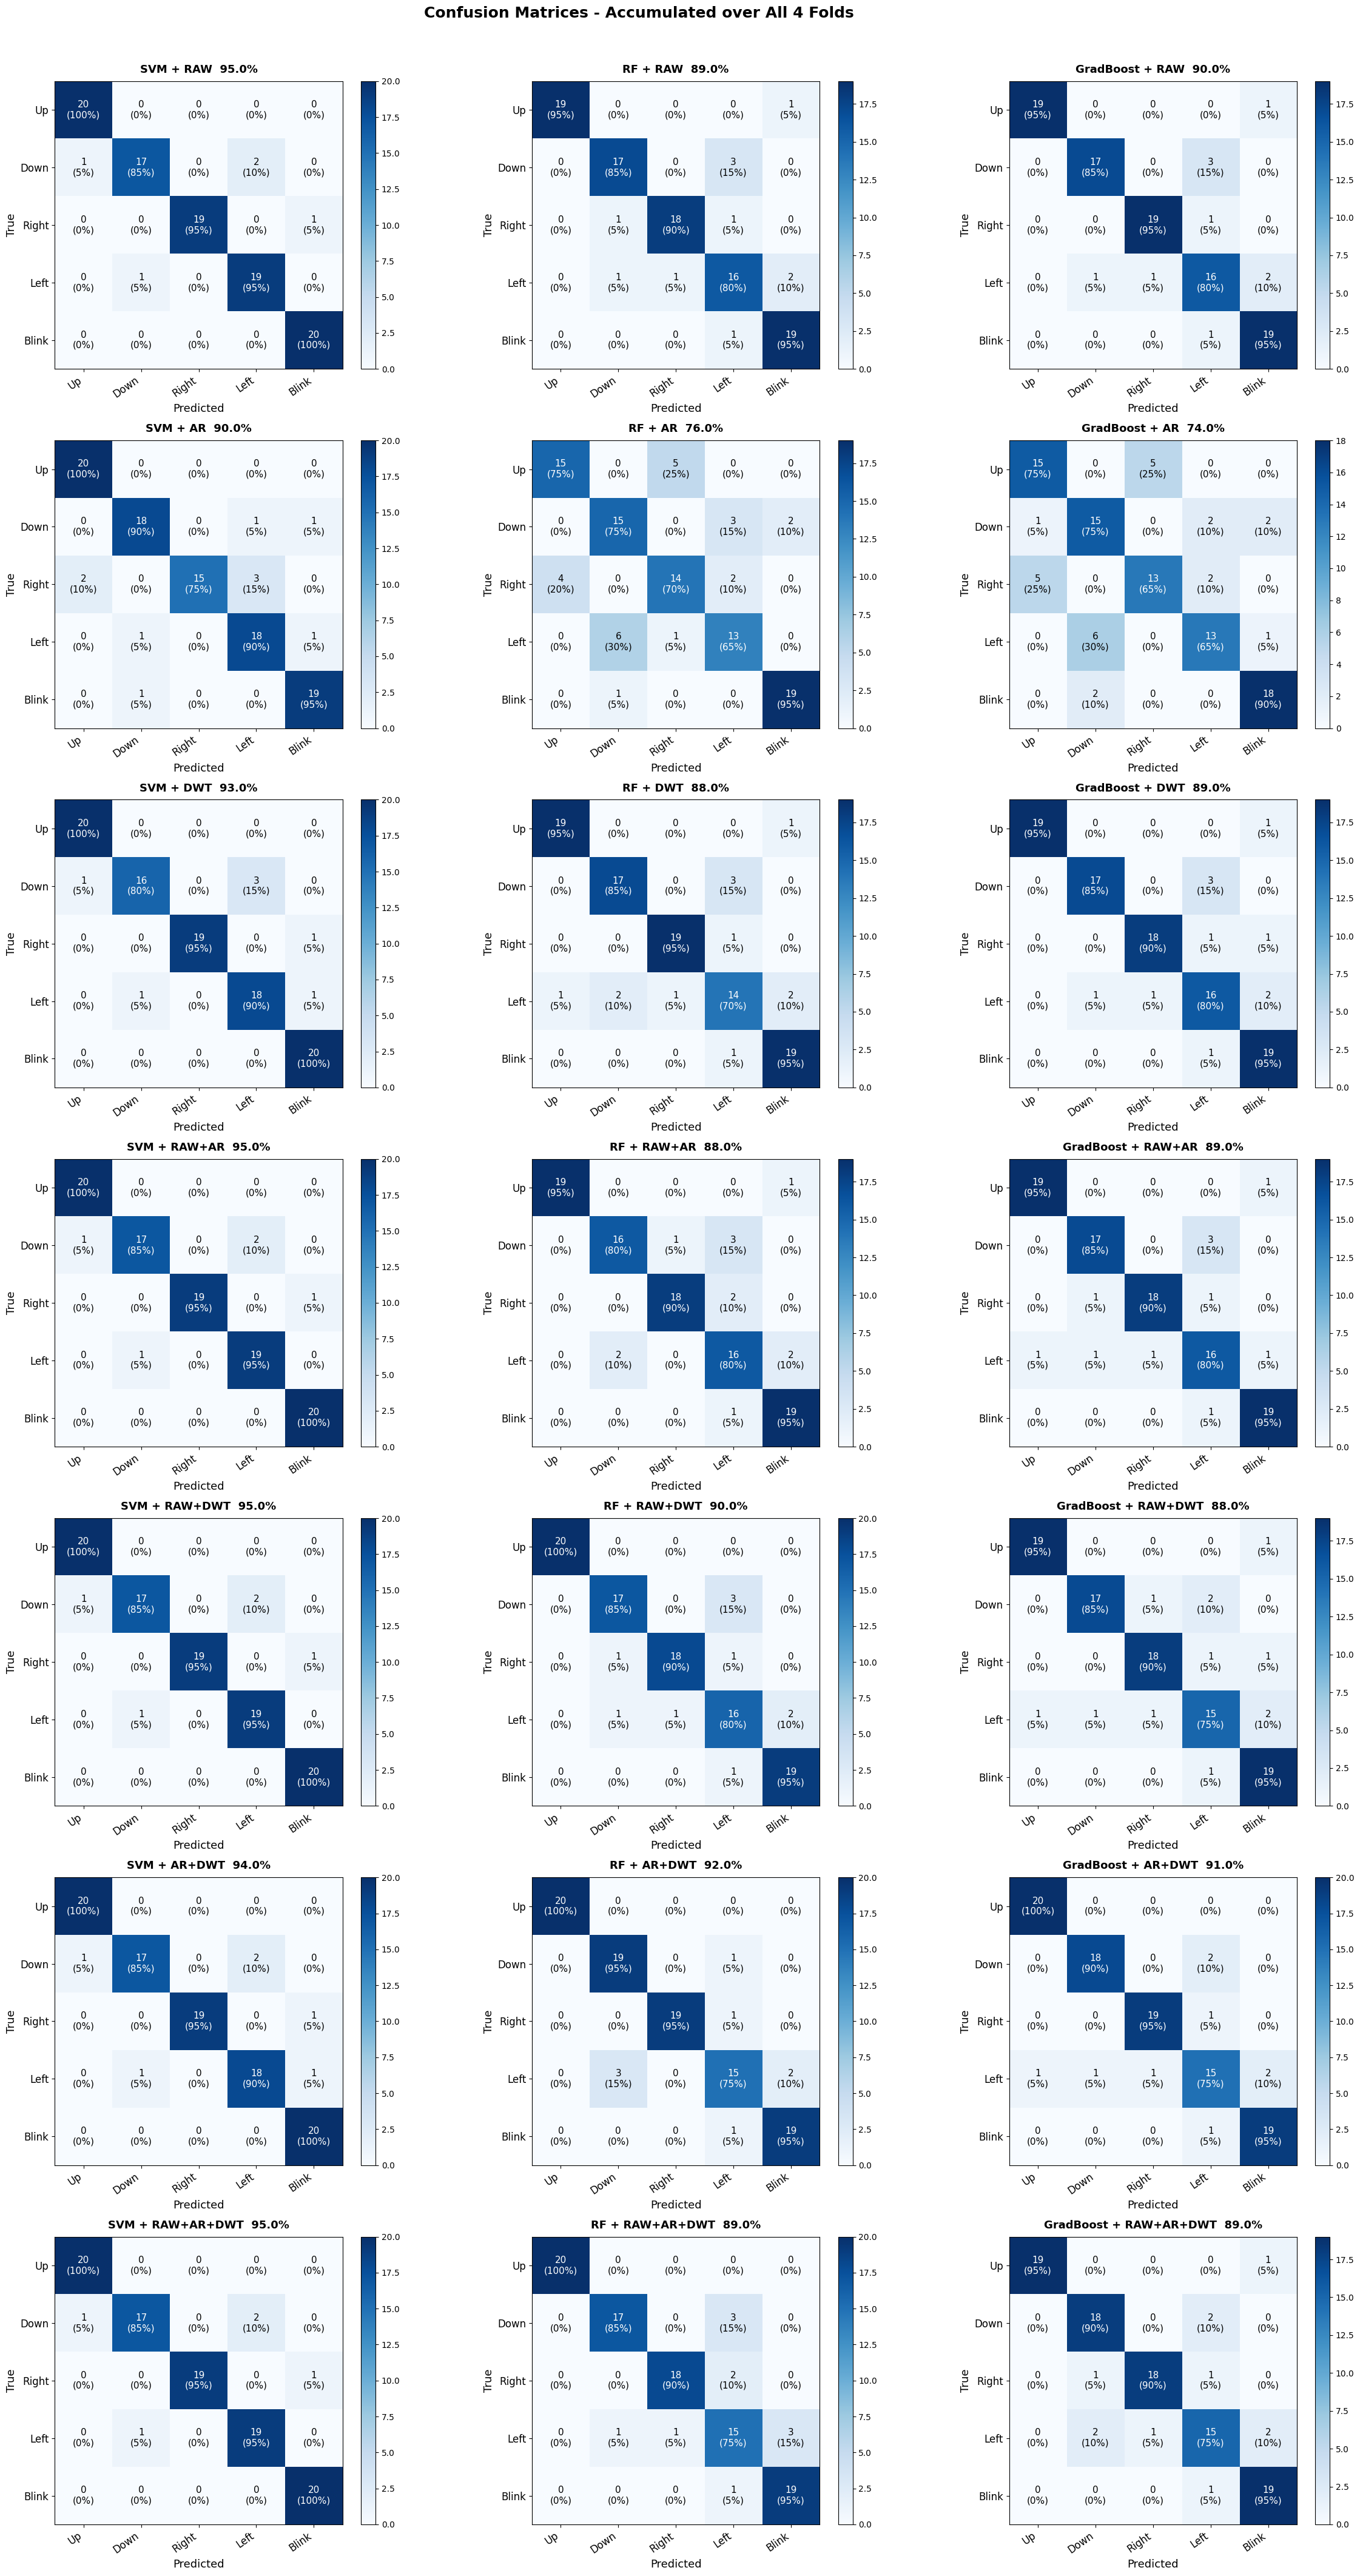

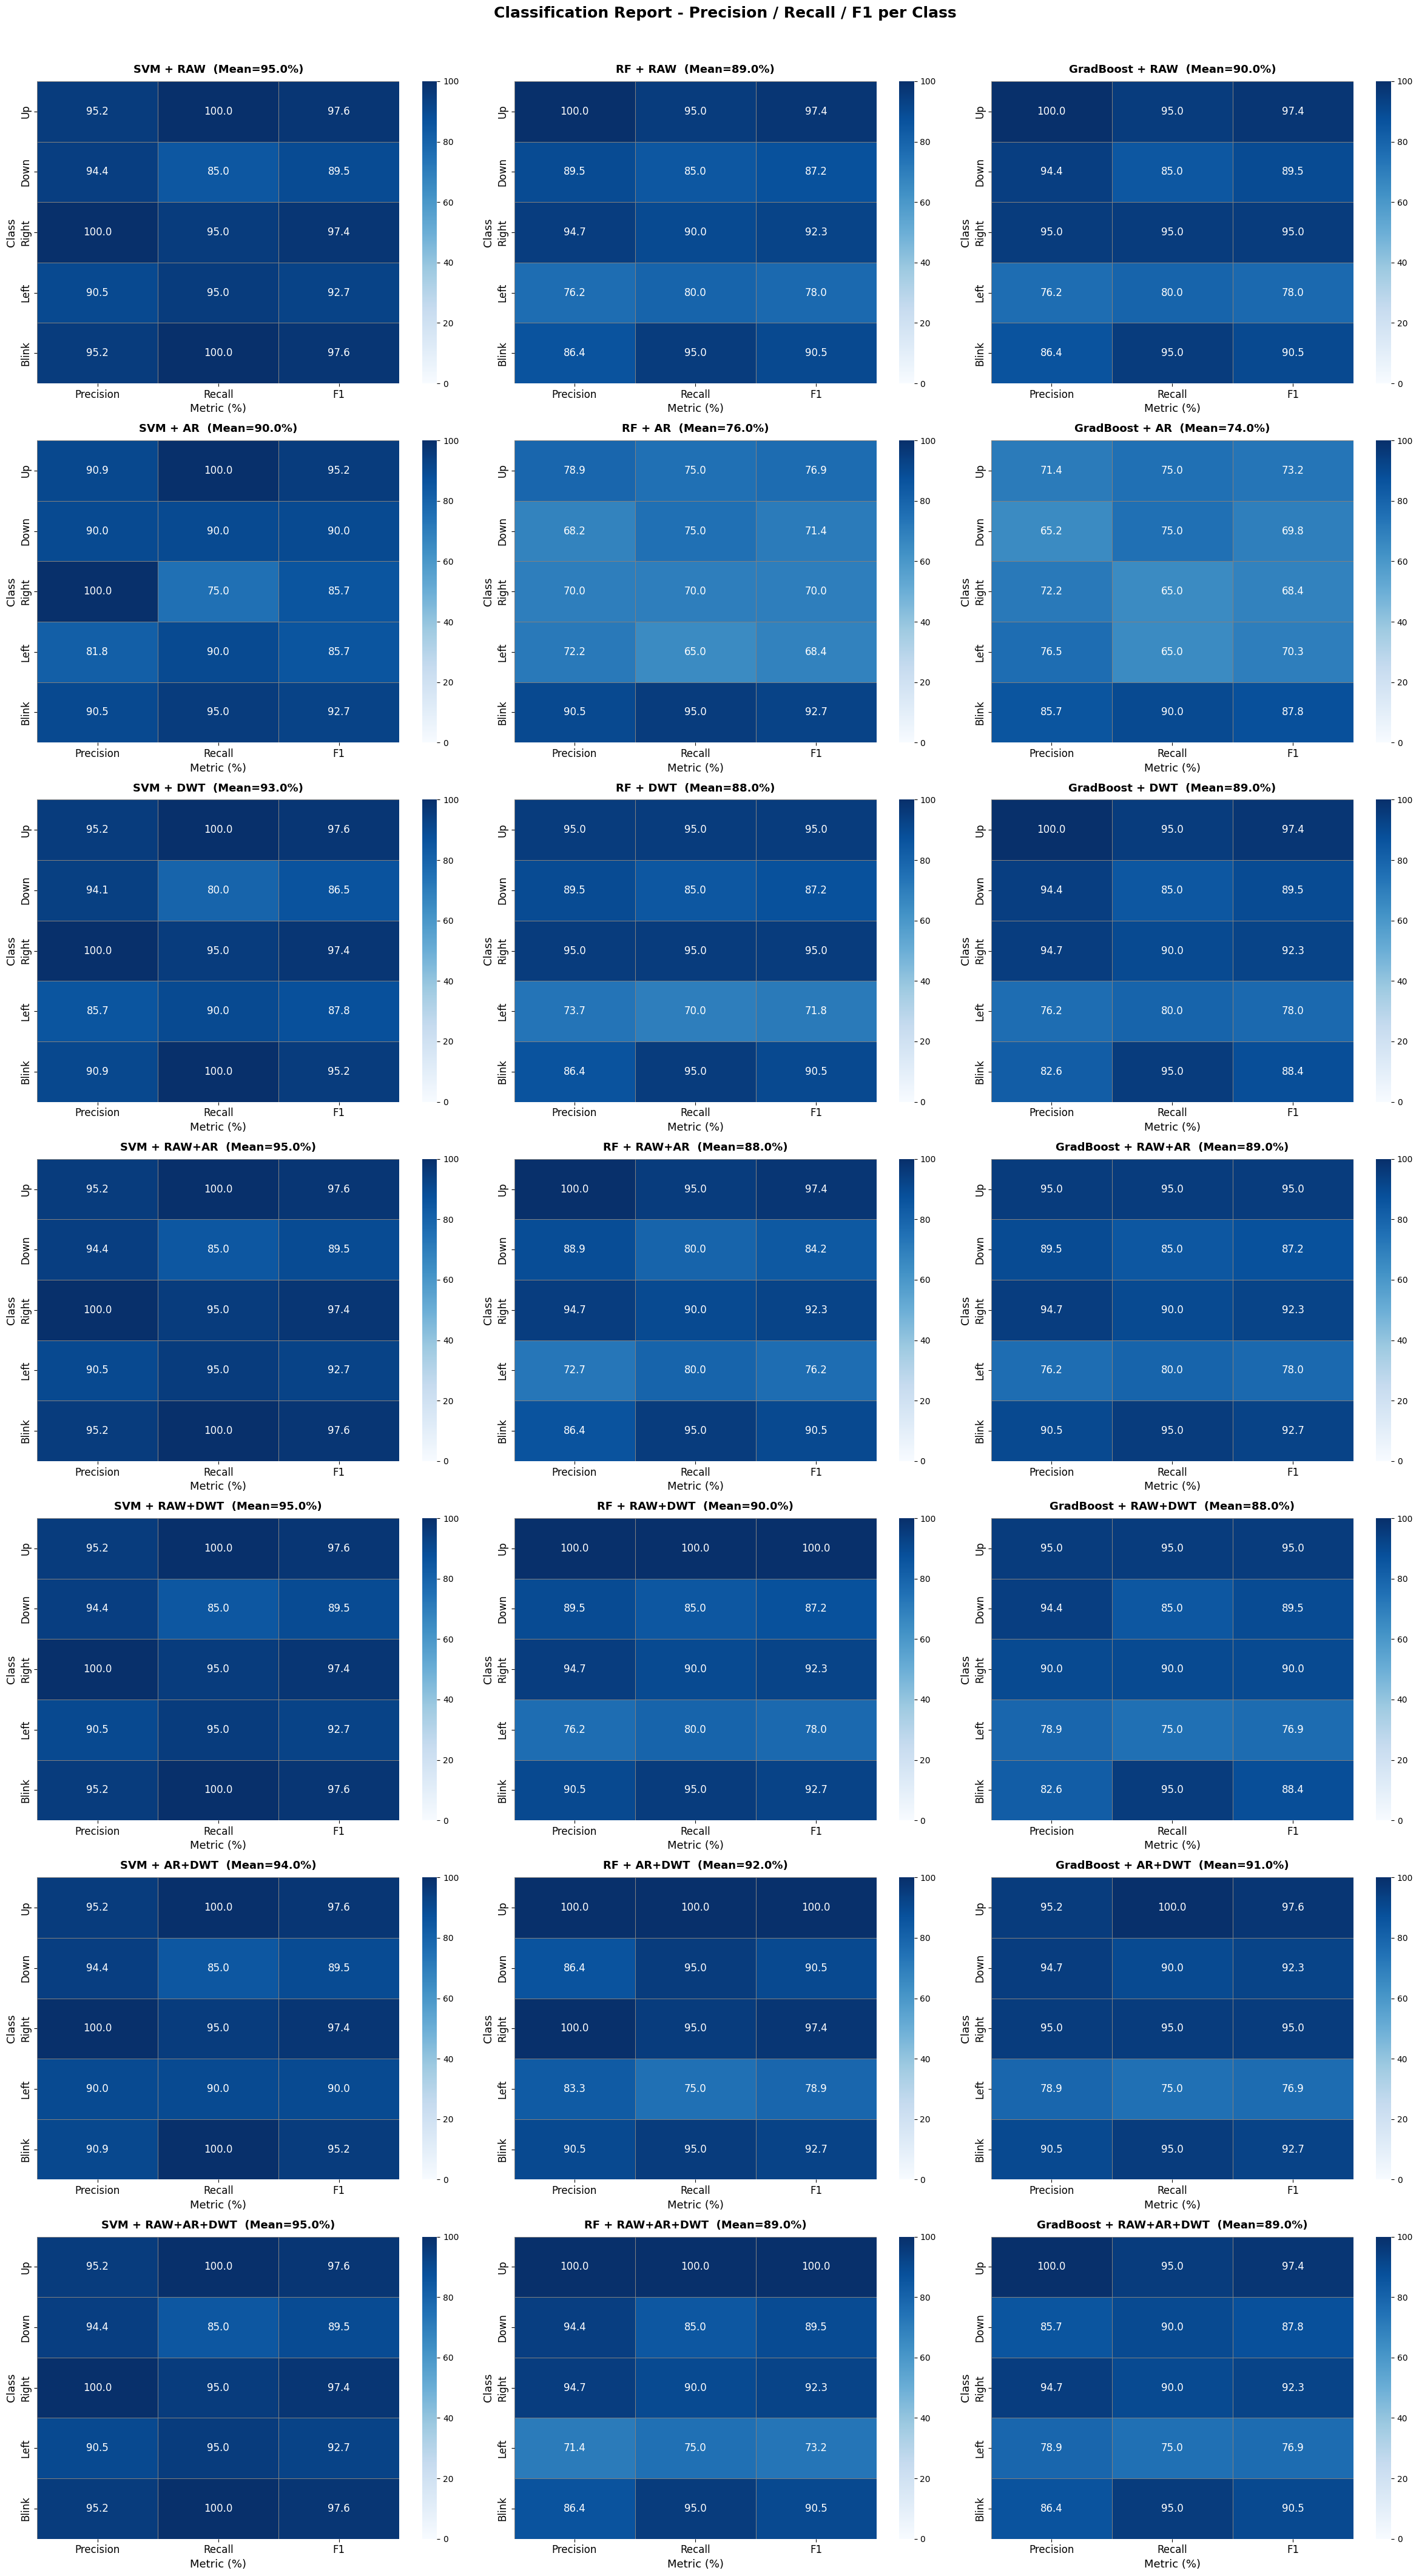

In [42]:
MODEL_NAMES   = ['SVM', 'RF', 'GradBoost']
FEATURE_TYPES = ['raw', 'ar', 'dwt', 'raw+ar', 'raw+dwt', 'ar+dwt', 'raw+ar+dwt']

colors_map = {
    'SVM'      : '#4C72B0',
    'RF'       : '#DD8452',
    'GradBoost': '#C44E52',
}


rows = []
for ft in FEATURE_TYPES:
    for mn in MODEL_NAMES:
        key = f'{ft}_{mn}'
        if key in results_mean:
            rows.append({
                'Feature'          : ft.upper(),
                'Model'            : mn,
                'Mean Accuracy (%)': round(results_mean[key], 2),
                'Std (%)'          : round(results_std[key],  2),
            })

comparison_df = pd.DataFrame(rows).sort_values(
    'Mean Accuracy (%)', ascending=False
).reset_index(drop=True)

print(comparison_df.to_string(index=True))

best = comparison_df.iloc[0]
print(f'\nBest: {best["Model"]} + {best["Feature"]} '
      f'-> {best["Mean Accuracy (%)"]:.2f}% +/- {best["Std (%)"]:.2f}%')


x     = np.arange(len(FEATURE_TYPES))
width = 0.22
n     = len(MODEL_NAMES)

fig, ax = plt.subplots(figsize=(20, 8))

for i, mn in enumerate(MODEL_NAMES):
    means  = [results_mean.get(f'{ft}_{mn}', 0) for ft in FEATURE_TYPES]
    stds   = [results_std.get(f'{ft}_{mn}',  0) for ft in FEATURE_TYPES]
    offset = (i - n / 2 + 0.5) * width
    bars   = ax.bar(x + offset, means, width,
                    label=mn, color=colors_map[mn],
                    yerr=stds, capsize=4, alpha=0.87)
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'{m:.1f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Type', fontsize=14)
ax.set_ylabel('Mean Accuracy (%)', fontsize=14)
ax.set_title('All Models x Feature Types - 4-Fold with Parameter Tuning',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([ft.upper() for ft in FEATURE_TYPES],
                   fontsize=12, rotation=15, ha='right')
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, 118)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot_comparison_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(len(FEATURE_TYPES), len(MODEL_NAMES),
                         figsize=(24, 6 * len(FEATURE_TYPES)))
fig.suptitle('Confusion Matrices - Accumulated over All 4 Folds',
             fontsize=18, fontweight='bold', y=1.01)

for row_idx, ft in enumerate(FEATURE_TYPES):
    for col_idx, mn in enumerate(MODEL_NAMES):
        ax     = axes[row_idx][col_idx]
        recs   = fold_details[ft][mn]
        y_true = np.concatenate([r['y_test'] for r in recs])
        y_pred = np.concatenate([r['y_pred'] for r in recs])
        cm      = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
        overall = np.trace(cm) / np.sum(cm) * 100
        thresh  = cm.max() / 2.0

        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(CLASS_NAMES)))
        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=12)
        ax.set_yticklabels(CLASS_NAMES, fontsize=12)
        ax.set_xlabel('Predicted', fontsize=13)
        ax.set_ylabel('True',      fontsize=13)
        ax.set_title(f'{mn} + {ft.upper()}  {overall:.1f}%',
                     fontsize=13, fontweight='bold', pad=10)

        for i in range(len(CLASS_NAMES)):
            for j in range(len(CLASS_NAMES)):
                pct = cm[i,j] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0
                ax.text(j, i, f'{cm[i,j]}\n({pct:.0f}%)',
                        ha='center', va='center', fontsize=11,
                        color='white' if cm[i,j] > thresh else 'black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot_confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(len(FEATURE_TYPES), len(MODEL_NAMES),
                         figsize=(24, 6 * len(FEATURE_TYPES)))
fig.suptitle('Classification Report - Precision / Recall / F1 per Class',
             fontsize=18, fontweight='bold', y=1.01)

for row_idx, ft in enumerate(FEATURE_TYPES):
    for col_idx, mn in enumerate(MODEL_NAMES):
        ax     = axes[row_idx][col_idx]
        recs   = fold_details[ft][mn]
        y_true = np.concatenate([r['y_test'] for r in recs])
        y_pred = np.concatenate([r['y_pred'] for r in recs])

        report = classification_report(
            y_true, y_pred,
            labels=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )
        matrix = np.array([
            [report[cls][m] * 100 for m in ['precision', 'recall', 'f1-score']]
            for cls in CLASS_NAMES
        ])

        sns.heatmap(
            matrix,
            annot=True, fmt='.1f', cmap='Blues',
            vmin=0, vmax=100,
            xticklabels=['Precision', 'Recall', 'F1'],
            yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='grey',
            annot_kws={'size': 12}, ax=ax
        )
        ax.set_title(
            f'{mn} + {ft.upper()}  (Mean={results_mean[f"{ft}_{mn}"]:.1f}%)',
            fontsize=13, fontweight='bold', pad=10
        )
        ax.set_xlabel('Metric (%)', fontsize=13)
        ax.set_ylabel('Class',      fontsize=13)
        ax.set_xticklabels(['Precision', 'Recall', 'F1'], fontsize=12)
        ax.set_yticklabels(CLASS_NAMES, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot_cls_report.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [44]:
import joblib, json as _json

MODELS_FOLDER = os.path.join(OUTPUT_FOLDER, 'saved_models')
os.makedirs(MODELS_FOLDER, exist_ok=True)

saved_models = {}

for feature_type in feature_types:
    for model_name in param_sets:

        X_all_list, y_all_list = [], []
        for fold in FOLDS:
            X_tr, y_tr, X_te, y_te = process_round_combined(fold['round'], feature_type)
            X_all_list.extend([X_tr, X_te])
            y_all_list.extend([y_tr, y_te])

        X_all = np.vstack(X_all_list)
        y_all = np.concatenate(y_all_list)


        params = best_params_log[feature_type][model_name]
        print(f'{feature_type} | {model_name} -> best params: {params}')


        if model_name == 'SVM':
            final_estimator = model_classes[model_name](**params)
        elif model_name == 'RF':
            final_estimator = model_classes[model_name](
                **params, random_state=42, n_jobs=-1
            )
        elif model_name == 'GradBoost':
            final_estimator = model_classes[model_name](
                **params, random_state=42
            )


        if model_name in NEEDS_SCALING:
            scaler = StandardScaler()
            X_fit  = scaler.fit_transform(X_all)
            final_estimator.fit(X_fit, y_all)
            to_save = {
                'scaler'        : scaler,
                'model'         : final_estimator,
                'needs_scaling' : True,
                'feature_type'  : feature_type,
                'class_names'   : CLASS_NAMES,
                'best_params'   : params,
            }
        else:
            final_estimator.fit(X_all, y_all)
            to_save = {
                'model'         : final_estimator,
                'needs_scaling' : False,
                'feature_type'  : feature_type,
                'class_names'   : CLASS_NAMES,
                'best_params'   : params,
            }

        fname = f'{feature_type}_{model_name}.joblib'
        fpath = os.path.join(MODELS_FOLDER, fname)
        joblib.dump(to_save, fpath)
        saved_models[f'{feature_type}_{model_name}'] = fpath
        print(f'  Saved -> {fname}')


manifest_path = os.path.join(MODELS_FOLDER, 'models_manifest.json')
with open(manifest_path, 'w') as mf:
    _json.dump(
        {
            'models': list(saved_models.keys()),
            'paths': saved_models,
            'feature_types': feature_types,
            'model_names': list(param_sets.keys()),
            'class_names': CLASS_NAMES,
        },
        mf,
        indent=2,
    )

print(f'\nAll {len(saved_models)} models saved to: {MODELS_FOLDER}')
print(f'Manifest saved: {manifest_path}')
print('\nTo load a model:')
print('  bundle = joblib.load(path)')
print('  model  = bundle["model"]')
print('  # if bundle["needs_scaling"]: X = bundle["scaler"].transform(X)')
print('  # pred  = model.predict(X)')


 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round3_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round3_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round4_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round4_Test_raw.xlsx
raw | SVM -> best params: {'kernel': 'rbf', 'C': 5, 'gamma': 'scale'}
  Saved -> raw_SVM.joblib
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Train_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round1_Test_raw.xlsx
 Saved: /content/drive/MyDrive/EOG_Output/Extracted_Features/Round2_Train_raw.x